In [2]:
%pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [wfdb]2m17/19 [aiohttp]normalizer]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


记录名称: <wfdb.io.record.Record object at 0x129620690>
采样率 360 Hz
导联名称 MLII
信号形状 (1500, 2)
前 10 个采样点： [-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


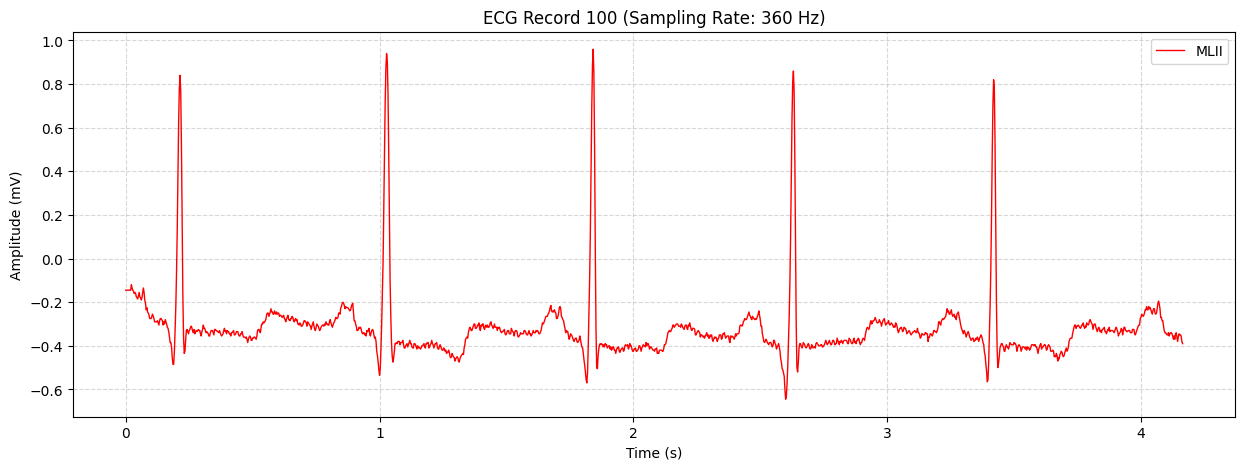

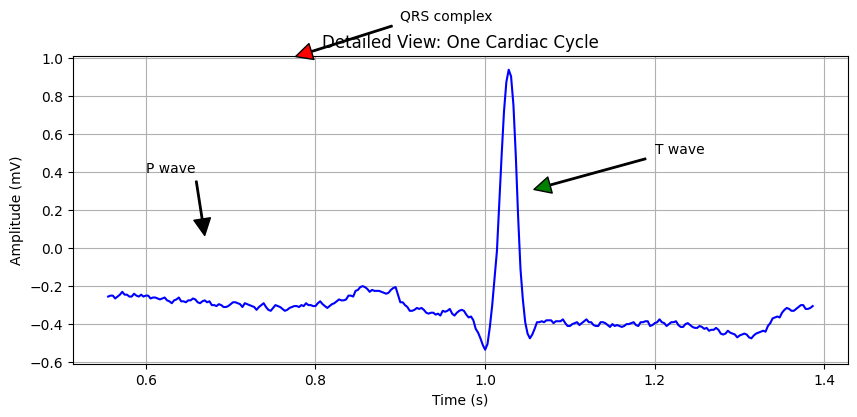

In [7]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# 1. 下载并读取 MIT-BIH 数据库中的第 100 号记录（前 1500 个采样点）
# 如果本地没有文件，wfdb 会尝试从 PhysioNet 云端拉取
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=1500)

# 2. 获取基本参数
fs = record.fs  # 采样率 (Hz)
signal = record.p_signal  # 信号数值 (单位通常为 mV)
n_samples = len(signal)
time = np.arange(n_samples) / fs  # 生成时间轴 (秒)


# 3. 绘图：整体观察（第一个导联）
plt.figure(figsize=(15, 5))
plt.plot(time, signal[:, 0], label=record.sig_name[0], color='red', linewidth=1)
plt.title(f"ECG Record 100 (Sampling Rate: {fs} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4. 绘图：精细观察一个心搏（约在 0.5s 到 1.5s 之间）
plt.figure(figsize=(10, 4))

# 选择 200 到 500 个采样点之间的片段
plt.plot(time[200:500], signal[200:500, 0], 'b', linewidth=1.5)
plt.title("Detailed View: One Cardiac Cycle")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

# 标注 P-QRS-T
plt.annotate(
    'P wave',
    xy=(0.67, 0.05),
    xytext=(0.60, 0.40),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1)
)

plt.annotate(
    'QRS complex',
    xy=(0.77, 1.0),
    xytext=(0.90, 1.20),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1)
)

plt.annotate(
    'T wave',
    xy=(1.05, 0.3),
    xytext=(1.20, 0.50),
    arrowprops=dict(facecolor='green', shrink=0.05, width=1)
)

plt.grid(True)
plt.show()


# ===== 新增部分 1：输出 record 里面的内容 =====
print("\n========== record 各字段详细内容 ==========")
for key, value in record.__dict__.items():
    print(f"\n--- {key} ---")
    print(value)



========== 基本参数确认 ==========
采样率 fs: 360 Hz
导联名称 sig_name: ['MLII', 'V5']
数据总长度 n_samples: 1500
信号矩阵形状 signal.shape: (1500, 2)


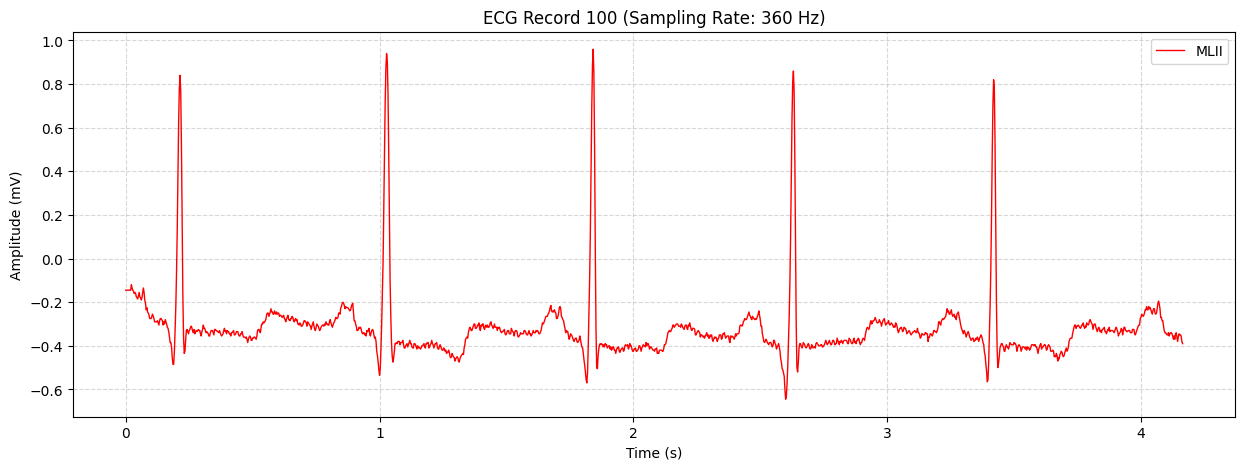

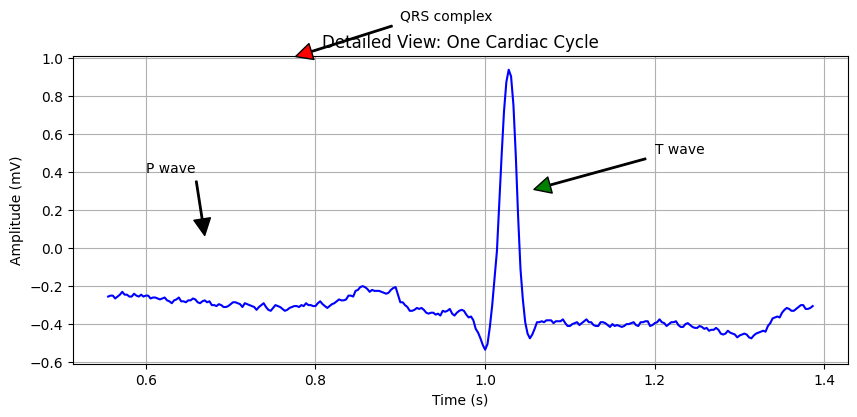


========== R 波检测结果 ==========
R 波位置（采样点）: [  77  370  663  947 1231]
R 波对应时间（秒）: [0.21388889 1.02777778 1.84166667 2.63055556 3.41944444]

========== 平均心率计算 ==========
R-R 间期（秒）: [0.81388889 0.81388889 0.78888889 0.78888889]
平均 R-R 间期: 0.8014 s
平均心率: 74.87 次/分 (bpm)


In [15]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# 1. 下载并读取 MIT-BIH 数据库中的第 100 号记录（前 1500 个采样点）
# 如果本地没有文件，wfdb 会尝试从 PhysioNet 云端拉取
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=1500)

# 2. 获取基本参数
fs = record.fs  # 采样率 (Hz)
signal = record.p_signal  # 信号数值 (单位通常为 mV)
n_samples = len(signal)
time = np.arange(n_samples) / fs  # 生成时间轴 (秒)

# ===== 新增部分 1：打印并确认基本信息 =====
print("\n========== 基本参数确认 ==========")
print(f"采样率 fs: {fs} Hz")
print(f"导联名称 sig_name: {record.sig_name}")
print(f"数据总长度 n_samples: {n_samples}")
print(f"信号矩阵形状 signal.shape: {signal.shape}")

# 3. 绘图：整体观察（第一个导联）
plt.figure(figsize=(15, 5))
plt.plot(time, signal[:, 0], label=record.sig_name[0], color='red', linewidth=1)
plt.title(f"ECG Record 100 (Sampling Rate: {fs} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4. 绘图：精细观察一个心搏（约在 0.5s 到 1.5s 之间）
plt.figure(figsize=(10, 4))

# 选择 200 到 500 个采样点之间的片段
plt.plot(time[200:500], signal[200:500, 0], 'b', linewidth=1.5)
plt.title("Detailed View: One Cardiac Cycle")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

# 标注 P-QRS-T
plt.annotate(
    'P wave',
    xy=(0.67, 0.05),
    xytext=(0.60, 0.40),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1)
)

plt.annotate(
    'QRS complex',
    xy=(0.77, 1.0),
    xytext=(0.90, 1.20),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1)
)

plt.annotate(
    'T wave',
    xy=(1.05, 0.3),
    xytext=(1.20, 0.50),
    arrowprops=dict(facecolor='green', shrink=0.05, width=1)
)

plt.grid(True)
plt.show()

# ===== 新增部分 2：定量计算平均心率（基于 R-R 间期） =====
# 使用第一个导联进行简单 R 波检测
ecg = signal[:, 0]

# 设定一个简单阈值：均值 + 1.0*标准差
threshold = np.mean(ecg) + 1.0 * np.std(ecg)

r_peaks = []
min_distance = int(0.6 * fs)  # 相邻 R 波最小间隔，避免重复检测

for i in range(1, len(ecg) - 1):
    if ecg[i] > ecg[i - 1] and ecg[i] > ecg[i + 1] and ecg[i] > threshold:
        if len(r_peaks) == 0:
            r_peaks.append(i)
        else:
            if i - r_peaks[-1] > min_distance:
                r_peaks.append(i)
            else:
                # 如果距离太近，保留更高的峰值
                if ecg[i] > ecg[r_peaks[-1]]:
                    r_peaks[-1] = i

r_peaks = np.array(r_peaks)

print("\n========== R 波检测结果 ==========")
print("R 波位置（采样点）:", r_peaks)
print("R 波对应时间（秒）:", time[r_peaks])

if len(r_peaks) >= 2:
    rr_intervals = np.diff(time[r_peaks])   # 单位：秒
    avg_rr = np.mean(rr_intervals)
    avg_hr = 60 / avg_rr

    print("\n========== 平均心率计算 ==========")
    print("R-R 间期（秒）:", rr_intervals)
    print(f"平均 R-R 间期: {avg_rr:.4f} s")
    print(f"平均心率: {avg_hr:.2f} 次/分 (bpm)")
else:
    print("\nR 波数量不足，无法计算平均心率。")


========== 基本参数确认 ==========
采样率 fs: 360 Hz
导联名称 sig_name: ['MLII', 'V5']
数据总长度 n_samples: 1500
信号矩阵形状 signal.shape: (1500, 2)


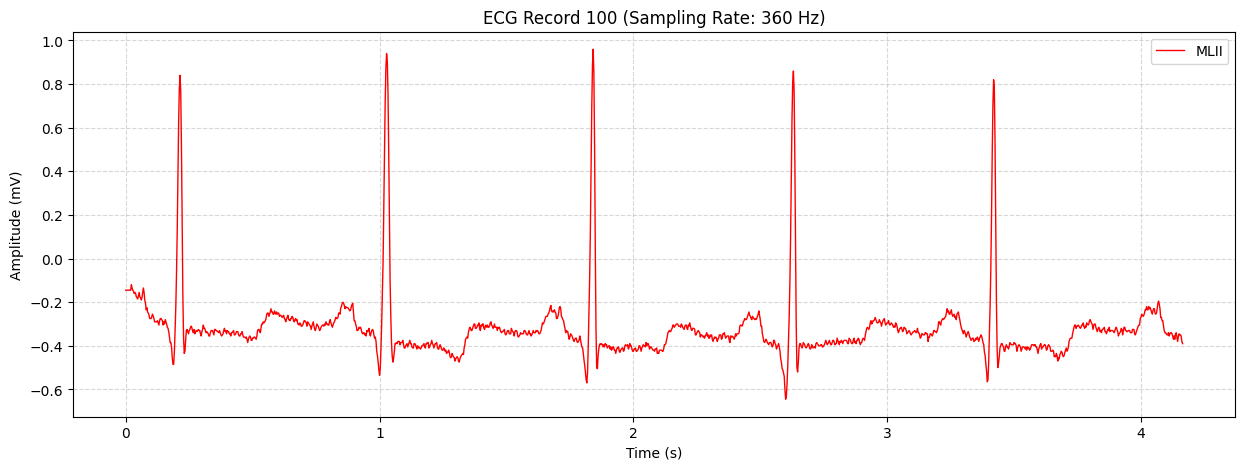


========== P-QRS-T 自动识别结果 ==========
P wave 位置: t = 0.8556 s, amp = -0.2000 mV
QRS 位置:    t = 1.0278 s, amp = 0.9400 mV
T wave 位置: t = 1.3722 s, amp = -0.3000 mV


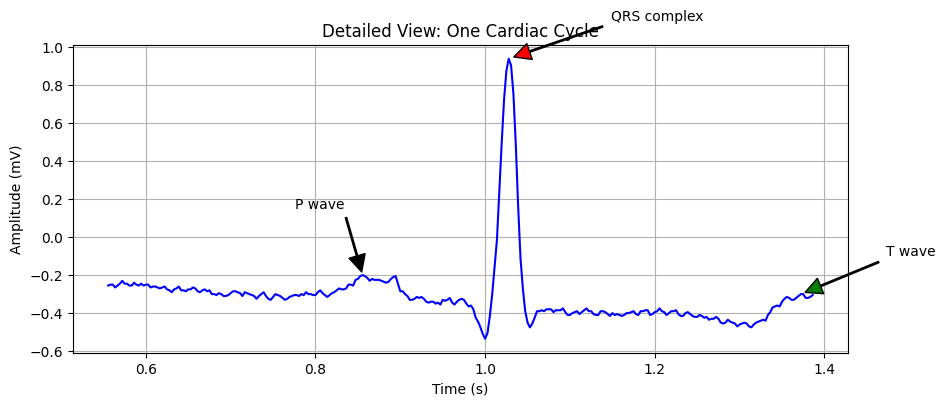


========== R 波检测结果 ==========
R 波位置（采样点）: [  77  370  663  947 1231]
R 波对应时间（秒）: [0.21388889 1.02777778 1.84166667 2.63055556 3.41944444]

========== 平均心率计算 ==========
R-R 间期（秒）: [0.81388889 0.81388889 0.78888889 0.78888889]
平均 R-R 间期: 0.8014 s
平均心率: 74.87 次/分 (bpm)


In [16]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# 1. 下载并读取 MIT-BIH 数据库中的第 100 号记录（前 1500 个采样点）
# 如果本地没有文件，wfdb 会尝试从 PhysioNet 云端拉取
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=1500)

# 2. 获取基本参数
fs = record.fs  # 采样率 (Hz)
signal = record.p_signal  # 信号数值 (单位通常为 mV)
n_samples = len(signal)
time = np.arange(n_samples) / fs  # 生成时间轴 (秒)

# ===== 新增部分 1：打印并确认基本信息 =====
print("\n========== 基本参数确认 ==========")
print(f"采样率 fs: {fs} Hz")
print(f"导联名称 sig_name: {record.sig_name}")
print(f"数据总长度 n_samples: {n_samples}")
print(f"信号矩阵形状 signal.shape: {signal.shape}")

# 3. 绘图：整体观察（第一个导联）
plt.figure(figsize=(15, 5))
plt.plot(time, signal[:, 0], label=record.sig_name[0], color='red', linewidth=1)
plt.title(f"ECG Record 100 (Sampling Rate: {fs} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4. 绘图：精细观察一个心搏（约在 0.5s 到 1.5s 之间）
plt.figure(figsize=(10, 4))

# 选择 200 到 500 个采样点之间的片段
start_idx = 200
end_idx = 500

seg_time = time[start_idx:end_idx]
seg_ecg = signal[start_idx:end_idx, 0]

plt.plot(seg_time, seg_ecg, 'b', linewidth=1.5)
plt.title("Detailed View: One Cardiac Cycle")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

# ===== 自动识别 P / QRS / T =====
# 思路：
# 1. QRS（这里用 R 峰代表）通常是这个局部片段里最高、最尖的峰
# 2. P 波一般出现在 R 峰前 0.08~0.25 s
# 3. T 波一般出现在 R 峰后 0.12~0.45 s

# 1) 自动找 QRS（用局部最大值近似 R 峰）
qrs_idx_local = np.argmax(seg_ecg)

# 2) 在 R 峰前的合理时间窗里找 P 波
p_search_start = max(0, qrs_idx_local - int(0.25 * fs))
p_search_end   = max(p_search_start + 1, qrs_idx_local - int(0.08 * fs))

p_idx_local = p_search_start + np.argmax(seg_ecg[p_search_start:p_search_end])

# 3) 在 R 峰后的合理时间窗里找 T 波
t_search_start = min(len(seg_ecg) - 1, qrs_idx_local + int(0.12 * fs))
t_search_end   = min(len(seg_ecg), qrs_idx_local + int(0.45 * fs))

# 防止窗口为空
if t_search_end <= t_search_start:
    t_search_start = min(len(seg_ecg) - 2, qrs_idx_local + 1)
    t_search_end = len(seg_ecg)

t_idx_local = t_search_start + np.argmax(seg_ecg[t_search_start:t_search_end])

# 取出自动识别后的坐标
p_x, p_y = seg_time[p_idx_local], seg_ecg[p_idx_local]
qrs_x, qrs_y = seg_time[qrs_idx_local], seg_ecg[qrs_idx_local]
t_x, t_y = seg_time[t_idx_local], seg_ecg[t_idx_local]

print("\n========== P-QRS-T 自动识别结果 ==========")
print(f"P wave 位置: t = {p_x:.4f} s, amp = {p_y:.4f} mV")
print(f"QRS 位置:    t = {qrs_x:.4f} s, amp = {qrs_y:.4f} mV")
print(f"T wave 位置: t = {t_x:.4f} s, amp = {t_y:.4f} mV")

# 标注 P-QRS-T（保留你的 annotate 逻辑，只把坐标改成自动识别结果）
plt.annotate(
    'P wave',
    xy=(p_x, p_y),
    xytext=(p_x - 0.08, p_y + 0.35),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1)
)

plt.annotate(
    'QRS complex',
    xy=(qrs_x, qrs_y),
    xytext=(qrs_x + 0.12, qrs_y + 0.20),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1)
)

plt.annotate(
    'T wave',
    xy=(t_x, t_y),
    xytext=(t_x + 0.10, t_y + 0.20),
    arrowprops=dict(facecolor='green', shrink=0.05, width=1)
)

plt.grid(True)
plt.show()
# ===== 新增部分 2：定量计算平均心率（基于 R-R 间期） =====
# 使用第一个导联进行简单 R 波检测
ecg = signal[:, 0]

# 设定一个简单阈值：均值 + 1.0*标准差
threshold = np.mean(ecg) + 1.0 * np.std(ecg)

r_peaks = []
min_distance = int(0.6 * fs)  # 相邻 R 波最小间隔，避免重复检测

for i in range(1, len(ecg) - 1):
    if ecg[i] > ecg[i - 1] and ecg[i] > ecg[i + 1] and ecg[i] > threshold:
        if len(r_peaks) == 0:
            r_peaks.append(i)
        else:
            if i - r_peaks[-1] > min_distance:
                r_peaks.append(i)
            else:
                # 如果距离太近，保留更高的峰值
                if ecg[i] > ecg[r_peaks[-1]]:
                    r_peaks[-1] = i

r_peaks = np.array(r_peaks)

print("\n========== R 波检测结果 ==========")
print("R 波位置（采样点）:", r_peaks)
print("R 波对应时间（秒）:", time[r_peaks])

if len(r_peaks) >= 2:
    rr_intervals = np.diff(time[r_peaks])   # 单位：秒
    avg_rr = np.mean(rr_intervals)
    avg_hr = 60 / avg_rr

    print("\n========== 平均心率计算 ==========")
    print("R-R 间期（秒）:", rr_intervals)
    print(f"平均 R-R 间期: {avg_rr:.4f} s")
    print(f"平均心率: {avg_hr:.2f} 次/分 (bpm)")
else:
    print("\nR 波数量不足，无法计算平均心率。")